In [1]:
#from alibi.explainers import ALE, plot_ale
import joblib
import funciones
import importlib

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

c:\Users\Jorge\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
importlib.reload(funciones)

<module 'funciones' from 'c:\\Users\\Jorge\\Documents\\Proyectos de programación\\TFG\\Modelos\\Jorge\\funciones.py'>

In [3]:
SPOOF = "..\\..\\Dataset\\Features\\spoof_features.csv"
BONAFIDE = '..\\..\\Dataset\\Features\\bonafide_features.csv'

RANDOM_STATE = 12
TEST_SPLIT = 0.2

In [4]:
df = funciones.carga_datos(ruta_bon=BONAFIDE, ruta_spo=SPOOF, random_state=RANDOM_STATE)

In [5]:
X = df.drop(columns=['label', 'filename'])
y = df['label']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SPLIT, random_state=RANDOM_STATE, stratify=y)

In [7]:
# Cargar el modelo
modelo_rf = joblib.load('modelo_Random_Forest.pkl')
modelo_lgbm = joblib.load('modelo_LightGBM.pkl')
modelo_svm = joblib.load('modelo_SVM.pkl')

In [8]:
# Eliminar características no relevantes
X_train_clean = X_train.drop(columns=['filename'], errors='ignore')
X_test_clean = X_test.drop(columns=['filename'], errors='ignore')

# Random Forest
## SHAP

In [ ]:
funciones.explica_shap(modelo=modelo_rf, X_train=X_train, X_test=X_test, n_show=1, local=True)

In [ ]:
funciones.explica_shap(modelo=modelo_rf, X_train=X_train, X_test=X_test, n_show=0, local=False)

In [ ]:
funciones.drop_features_explica(
    modelo=modelo_rf,
    model_name='Random Forest', 
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test, 
    y_test=y_test,
    feats='spectral_flatness', 
    n_show=5, 
    evalua_modelo=True,
    explicacion='shap'
)

In [ ]:
funciones.drop_features_explica(
    modelo=modelo_rf,
    model_name='Random Forest',
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test, 
    y_test=y_test,
    feats=['spectral_flatness', 'mfcc_1_mean', 'spectral_bandwidth'], 
    n_show=5, 
    evalua_modelo=True,
    explicacion='shap'
)

## LIME

In [ ]:
html = funciones.explica_lime(modelo=modelo_rf, columnas=X.columns, X_train=X_train, X_test=X_test)

display(html)

## DiCE

In [ ]:
funciones.explica_dice(modelo=modelo_rf, X_train=X_train_clean, y_train=y_train, X_test=X_test)

# LightGBM
## SHAP

In [ ]:
funciones.explica_shap(modelo=modelo_lgbm, X_train=X_train, X_test=X_test, n_show=1, local=True)

In [ ]:
funciones.explica_shap(modelo=modelo_lgbm, X_train=X_train, X_test=X_test, n_show=0, local=False)

In [ ]:
funciones.drop_features_explica(
    modelo=modelo_lgbm,
    model_name='LightGBM', 
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test, 
    y_test=y_test,
    feats='spectral_flatness', 
    n_show=3, 
    evalua_modelo=True,
    explicacion='shap'
)

In [ ]:
funciones.drop_features_explica(
    modelo=modelo_lgbm,
    model_name='LightGBM',
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test, 
    y_test=y_test,
    feats=['spectral_flatness', 'mfcc_1_mean'], 
    n_show=3, 
    evalua_modelo=True,
    explicacion='shap'
)

## LIME

In [ ]:
html = funciones.explica_lime(modelo=modelo_lgbm, columnas=X.columns, X_train=X_train, X_test=X_test)

display(html)

## DiCE

In [ ]:
funciones.explica_dice(modelo=modelo_lgbm, X_train=X_train_clean, y_train=y_train, X_test=X_test)

# SVM
## SHAP

In [9]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    modelo_svm
])

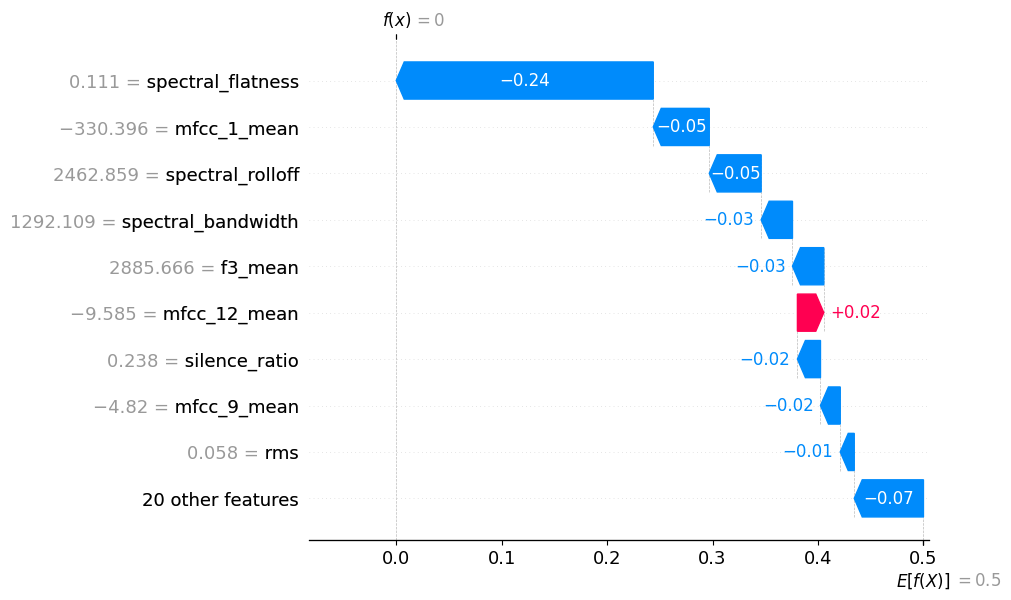

In [14]:
funciones.explica_shap(modelo=modelo_svm, X_train=X_train, X_test=X_test, n_show=1, local=True)

c:\Users\Jorge\Documents\Proyectos de programación\TFG\Modelos\Jorge\funciones.py:202: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


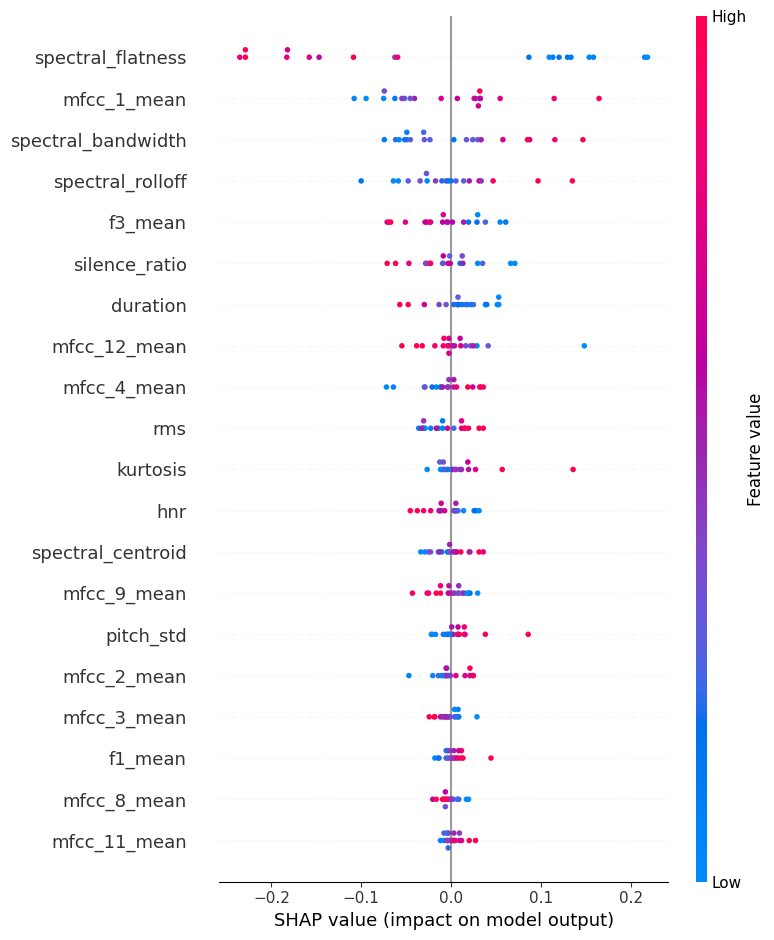

In [11]:
funciones.explica_shap(modelo=modelo_svm, X_train=X_train, X_test=X_test, n_show=1, local=False)

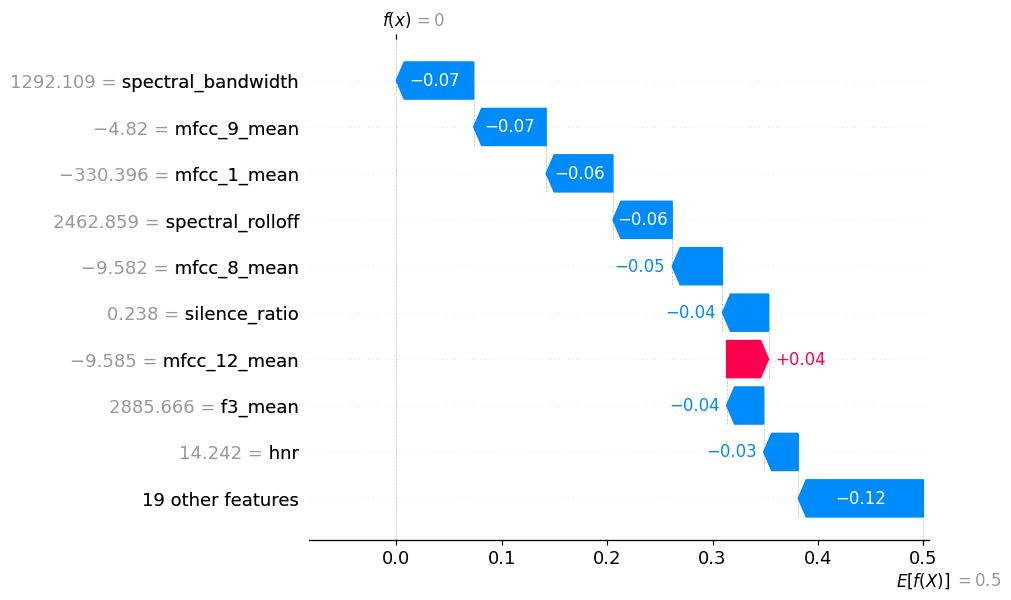

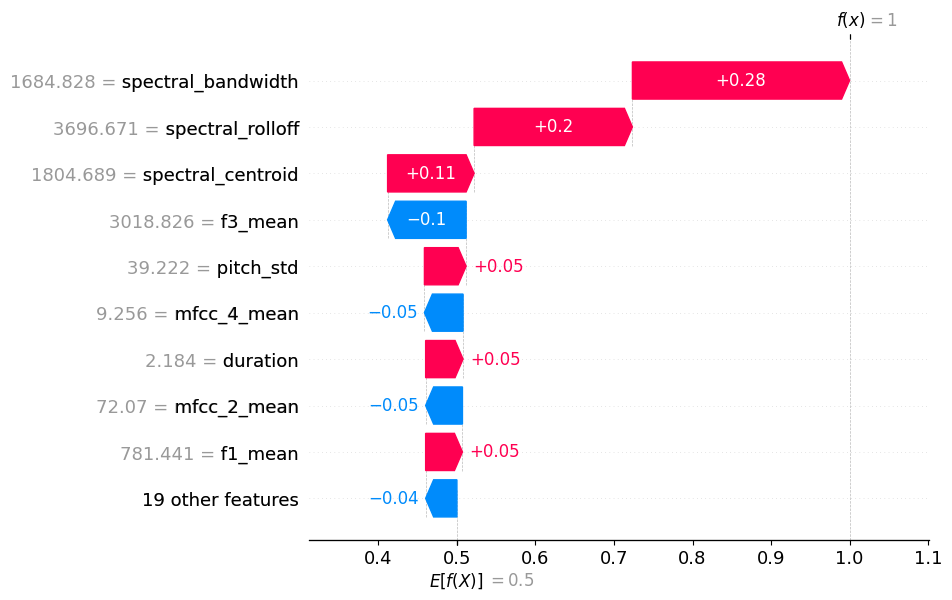

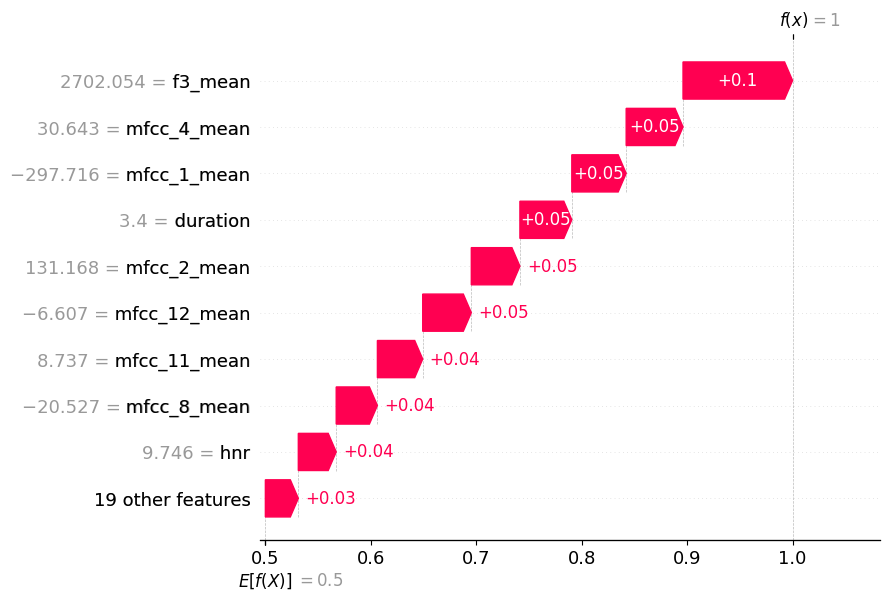


 EVALUACIÓN: SVM

MÉTRICAS PRINCIPALES:
   • Accuracy:  1.0000  (Porcentaje total de aciertos)
   • Precision: 1.0000  (De los que dije que eran reales, ¿cuántos lo eran?)
   • Recall:    1.0000  (De los reales, ¿cuántos detecté?)
   • F1-Score:  1.0000  (Balance precision-recall)
   • AUC-ROC:   1.0000  (Capacidad discriminativa)
   • MCC:       1.0000  (Coeficiente de correlación de Matthews)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Real (1)     1.0000    1.0000    1.0000        10
      IA (0)     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20


ANÁLISIS DE ERRORES:
   • Verdaderos Negativos (Reales bien clasificados): 10
   • Verdaderos Positivos (IA bien clasificados): 10
   • Falsos Positivos (Reales clasificados como IA): 0
   • Falsos Negativos (IA clasificados como Reales): 0
   • Err

In [12]:
funciones.drop_features_explica(
    modelo=modelo_svm,
    model_name='SVM', 
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test, 
    y_test=y_test,
    feats='spectral_flatness', 
    n_show=3, 
    evalua_modelo=True,
    explicacion='shap'
)

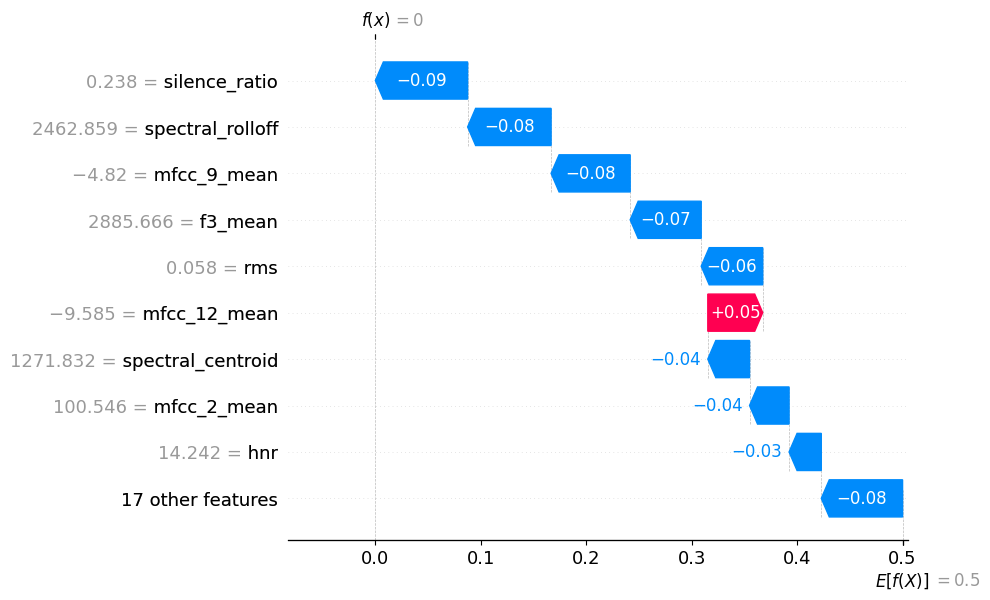

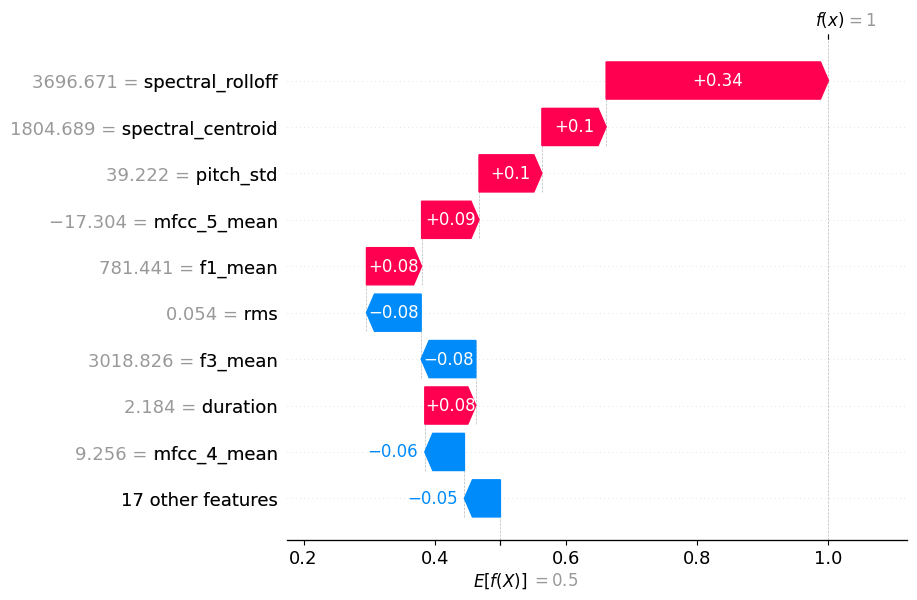

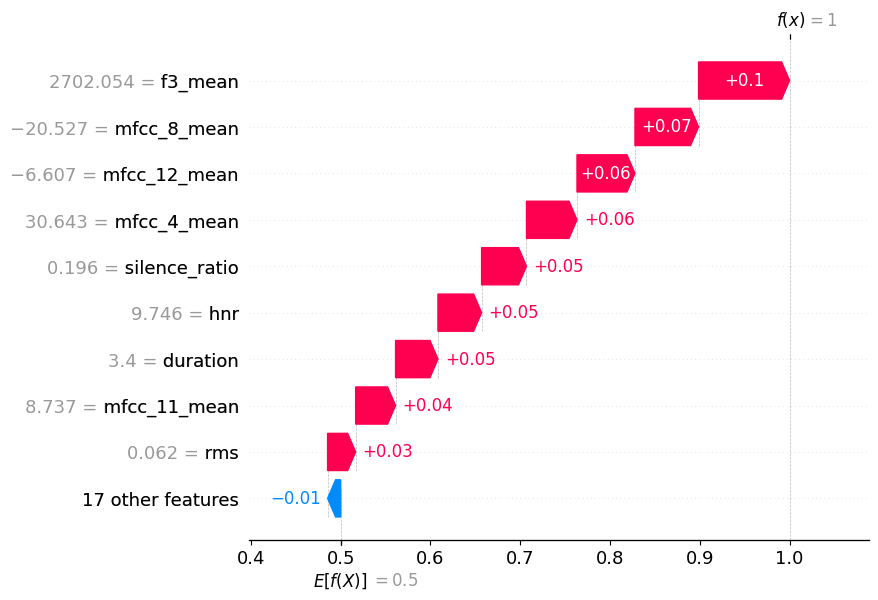


 EVALUACIÓN: SVM

MÉTRICAS PRINCIPALES:
   • Accuracy:  1.0000  (Porcentaje total de aciertos)
   • Precision: 1.0000  (De los que dije que eran reales, ¿cuántos lo eran?)
   • Recall:    1.0000  (De los reales, ¿cuántos detecté?)
   • F1-Score:  1.0000  (Balance precision-recall)
   • AUC-ROC:   1.0000  (Capacidad discriminativa)
   • MCC:       1.0000  (Coeficiente de correlación de Matthews)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Real (1)     1.0000    1.0000    1.0000        10
      IA (0)     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20


ANÁLISIS DE ERRORES:
   • Verdaderos Negativos (Reales bien clasificados): 10
   • Verdaderos Positivos (IA bien clasificados): 10
   • Falsos Positivos (Reales clasificados como IA): 0
   • Falsos Negativos (IA clasificados como Reales): 0
   • Err

In [13]:
funciones.drop_features_explica(
    modelo=modelo_svm,
    model_name='SVM',
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test, 
    y_test=y_test,
    feats=['spectral_flatness', 'mfcc_1_mean', 'spectral_bandwidth'], 
    n_show=3, 
    evalua_modelo=True,
    explicacion='shap'
)

## LIME

In [ ]:
html = funciones.explica_lime(modelo=modelo_svm, columnas=X.columns, X_train=X_train, X_test=X_test)

display(html)

## DiCE

In [ ]:
funciones.explica_dice(modelo=modelo_svm, X_train=X_train_clean, y_train=y_train, X_test=X_test, escalar=True)